N=  2: A_final=0.906, v_final=0.3853
N=  3: A_final=1.398, v_final=0.4276
N=  4: A_final=1.965, v_final=0.4548
N= 10: A_final=7.332, v_final=0.5170
N= 20: A_final=23.075, v_final=0.5365

Evolution plot saved.

Power law fit: A* = 0.792 * N^0.602
Fixed point plot saved.


  Z_N VOS Scaling Parameters (d_N = d_2/N)
   N |       A* |       v* |  k_w(v*)
----------------------------------------
   2 |    1.280 |   0.4196 |   0.4915
   3 |    1.587 |   0.4382 |   0.4140
   4 |    1.856 |   0.4504 |   0.3640
   5 |    2.100 |   0.4593 |   0.3281
   6 |    2.326 |   0.4661 |   0.3006
   8 |    2.740 |   0.4762 |   0.2607
  10 |    3.120 |   0.4835 |   0.2325
  15 |    3.970 |   0.4952 |   0.1871
  20 |    4.735 |   0.5026 |   0.1592
  30 |    6.116 |   0.5116 |   0.1255
  50 |    8.570 |   0.5209 |   0.0912


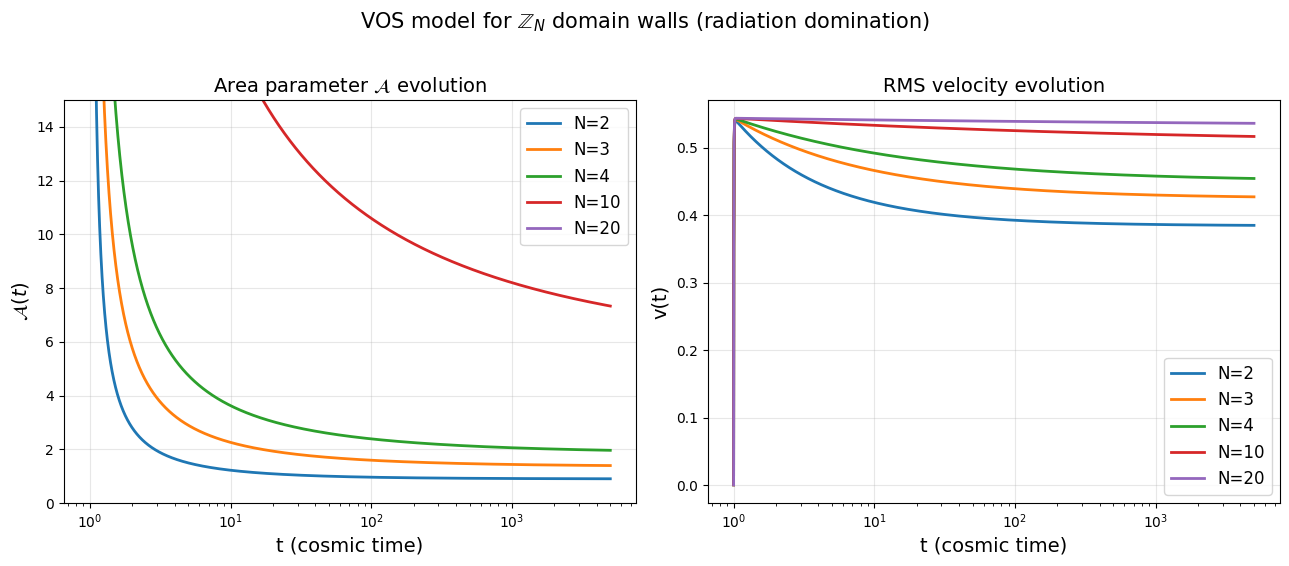

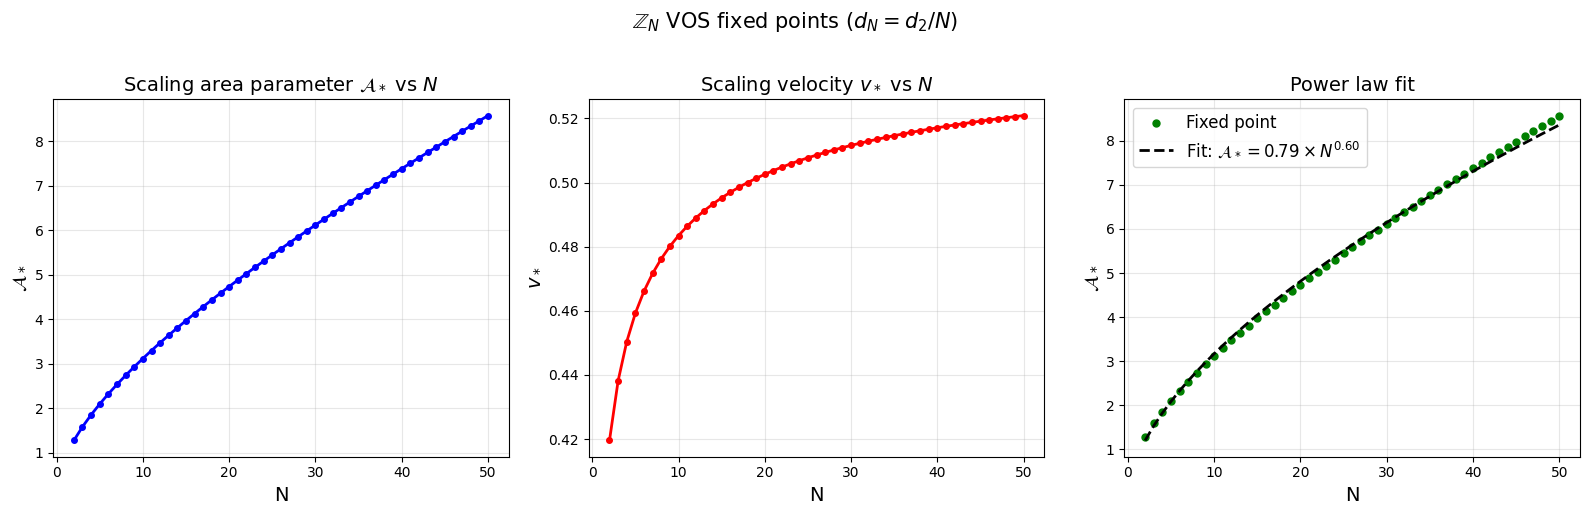

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Z_2 VOS parameters from paper
d2 = 0.26
r = 1.42
q_param = 3.35
b_k = 1.08
k0 = 1.77

alpha_junction = 0.5 #junction friction term

def k_w(v):
    return k0 * (1 - (q_param * v**2)**b_k) / (1 + (q_param * v**2)**b_k)

def vos_odes(t, y, N):
    ell = float(y[0])
    v = float(y[1])
    
    v = max(min(v, 0.9999), 1e-10)
    ell = max(ell, 1e-15)
    
    H = 0.5 / t  # radiation domination
    
    kw = k_w(v)
    d_N = d2 *2/N*(1/(1+alpha_junction*(N-2)))
    chopping = (k0 - kw)
    
    dell_dt = (1 + 3*v**2) * H * ell + d_N * chopping**r
    dv_dt = (1 - v**2) * (kw / ell - 3*H*v)
    
    return [float(dell_dt), float(dv_dt)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

t_span = (1.0, 5000.0)
t_eval = np.logspace(0, np.log10(5000), 3000)

colors = {2: 'C0', 3: 'C1', 4: 'C2', 10: 'C3', 20: 'C4'}

for N in [2, 3, 4, 10, 20]:
    ell_i = 0.01
    v_i = 1e-3
    
    sol = solve_ivp(lambda t, y: vos_odes(t, y, N), t_span, [ell_i, v_i], 
                     t_eval=t_eval, method='RK45', rtol=1e-10, atol=1e-12,
                     max_step=1.0)
    
    if sol.success:
        t = sol.t
        ell = sol.y[0]
        v = sol.y[1]
        H = 0.5 / t
        A = 1.0 / (2*H*ell)
        
        axes[0].plot(t, A, label=f'N={N}', color=colors[N], linewidth=2)
        axes[1].plot(t, v, label=f'N={N}', color=colors[N], linewidth=2)
        
        # Print final scaling values
        print(f"N={N:3d}: A_final={A[-1]:.3f}, v_final={v[-1]:.4f}")
    else:
        print(f"N={N}: integration failed - {sol.message}")

axes[0].set_xlabel('t (cosmic time)', fontsize=14)
axes[0].set_ylabel(r'$\mathcal{A}(t)$', fontsize=14)
axes[0].set_title(r'Area parameter $\mathcal{A}$ evolution', fontsize=14)
axes[0].set_xscale('log')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 15)

axes[1].set_xlabel('t (cosmic time)', fontsize=14)
axes[1].set_ylabel('v(t)', fontsize=14)
axes[1].set_title('RMS velocity evolution', fontsize=14)
axes[1].set_xscale('log')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle(r'VOS model for $\mathbb{Z}_N$ domain walls (radiation domination)', fontsize=15, y=1.02)
plt.tight_layout()
# plt.savefig('/home/claude/vos_zn_evolution.png', dpi=150, bbox_inches='tight')
print("\nEvolution plot saved.")

# Also redo the fixed point summary with a nicer plot
from scipy.optimize import fsolve

def fixed_point_eqs(vars, N):
    v, A = vars
    kw = k_w(v)
    chopping = max(k0 - kw, 1e-15)
    eq1 = A - 3*v / (2*kw)
    eq2 = A - N * (1 - 3*v**2) / (2 * d2 * chopping**r)
    return [eq1, eq2]

N_dense = np.arange(2, 51)
A_stars = []
v_stars = []

v_g, A_g = 0.42, 1.28
for N in N_dense:
    sol = fsolve(fixed_point_eqs, [v_g, A_g], args=(N,), full_output=True)
    v_s, A_s = sol[0]
    A_stars.append(A_s)
    v_stars.append(v_s)
    v_g, A_g = v_s, A_s  # use as next guess

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))

axes2[0].plot(N_dense, A_stars, 'b-', linewidth=2)
axes2[0].plot(N_dense, A_stars, 'bo', markersize=4)
axes2[0].set_xlabel('N', fontsize=14)
axes2[0].set_ylabel(r'$\mathcal{A}_*$', fontsize=14)
axes2[0].set_title(r'Scaling area parameter $\mathcal{A}_*$ vs $N$', fontsize=14)
axes2[0].grid(True, alpha=0.3)

axes2[1].plot(N_dense, v_stars, 'r-', linewidth=2)
axes2[1].plot(N_dense, v_stars, 'ro', markersize=4)
axes2[1].set_xlabel('N', fontsize=14)
axes2[1].set_ylabel(r'$v_*$', fontsize=14)
axes2[1].set_title(r'Scaling velocity $v_*$ vs $N$', fontsize=14)
axes2[1].grid(True, alpha=0.3)

# Fit A* vs N to check scaling
from numpy.polynomial import polynomial as P
# Try A* = a * N^alpha
log_N = np.log(np.array(N_dense, dtype=float))
log_A = np.log(np.array(A_stars))
coeffs = np.polyfit(log_N, log_A, 1)
alpha_fit = coeffs[0]
prefactor = np.exp(coeffs[1])

axes2[2].plot(N_dense, A_stars, 'go', markersize=5, label='Fixed point')
axes2[2].plot(N_dense, prefactor * np.array(N_dense, dtype=float)**alpha_fit, 'k--', 
              linewidth=2, label=rf'Fit: $\mathcal{{A}}_* = {prefactor:.2f} \times N^{{{alpha_fit:.2f}}}$')
axes2[2].set_xlabel('N', fontsize=14)
axes2[2].set_ylabel(r'$\mathcal{A}_*$', fontsize=14)
axes2[2].set_title(r'Power law fit', fontsize=14)
axes2[2].legend(fontsize=12)
axes2[2].grid(True, alpha=0.3)

plt.suptitle(r'$\mathbb{Z}_N$ VOS fixed points ($d_N = d_2/N$)', fontsize=15, y=1.02)
plt.tight_layout()
# plt.savefig('/home/claude/vos_zn_fixedpoints.png', dpi=150, bbox_inches='tight')
print(f"\nPower law fit: A* = {prefactor:.3f} * N^{alpha_fit:.3f}")
print("Fixed point plot saved.")

# Print full table
print("\n\n========================================")
print("  Z_N VOS Scaling Parameters (d_N = d_2/N)")
print("========================================")
print(f"{'N':>4s} | {'A*':>8s} | {'v*':>8s} | {'k_w(v*)':>8s}")
print("-" * 40)
for i, N in enumerate(N_dense):
    if N in [2,3,4,5,6,8,10,15,20,30,50]:
        print(f"{N:4d} | {A_stars[i]:8.3f} | {v_stars[i]:8.4f} | {k_w(v_stars[i]):8.4f}")

name                 N       A*       v*     v_src     dN_eff  alpha_eff     A_back
--------------------------------------------------------------------------------------------
Z2                   2    0.900    0.385  inferred 2.6011e-01        nan      0.900
Z3                   3    1.800    0.448  inferred 6.8702e-02 1.5230e+00      1.800
Z4_beta_0p01         4    1.500    0.433  inferred 9.6353e-02 1.7461e-01      1.500


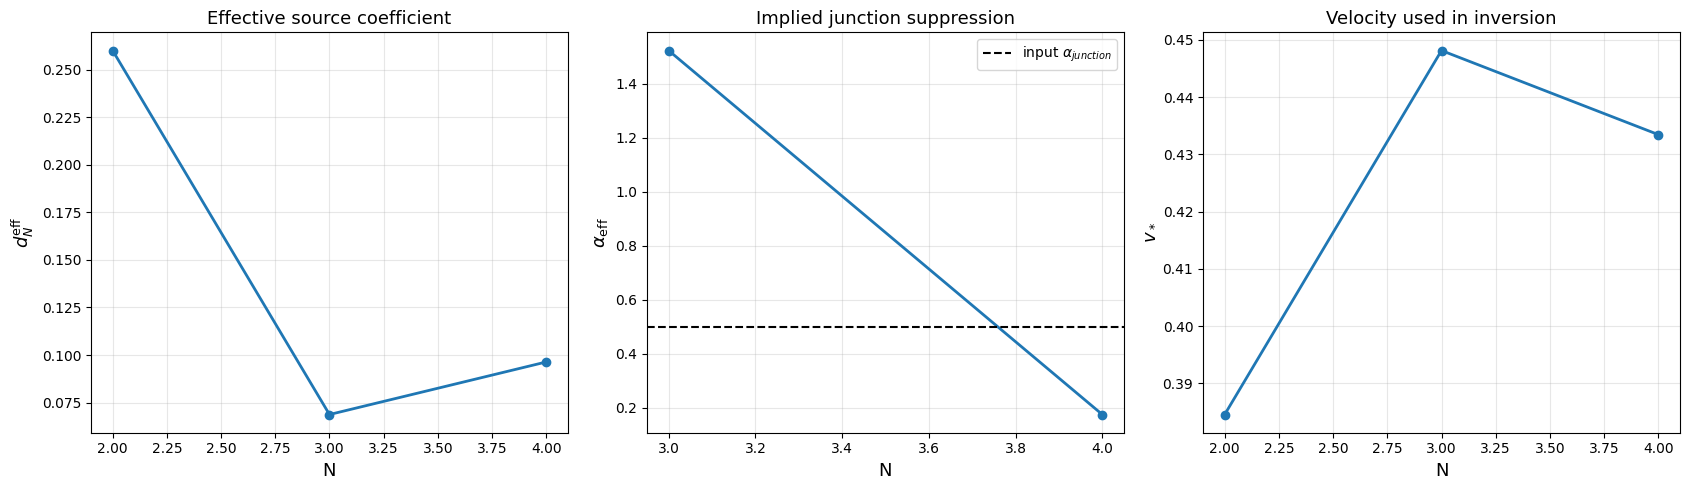

In [11]:
# Inversion utilities: estimate an effective d_N from late-time plateaus
# Use the notebook's VOS variables: d2, r, q_param, b_k, k0, alpha_junction, k_w(v)

from scipy.optimize import brentq


def infer_vstar_from_Astar(A_star, v_min=1e-6, v_max=0.57):
    """Infer v_* from A_* using A_* = 3 v_*/(2 k_w(v_*))."""
    if A_star <= 0:
        raise ValueError("A_star must be positive")

    def f(v):
        return A_star - 3.0 * v / (2.0 * k_w(v))

    # Preferred path: strict root find in the physical branch v < 1/sqrt(3) ~ 0.577.
    f_lo = f(v_min)
    f_hi = f(v_max)
    if f_lo * f_hi <= 0:
        return brentq(f, v_min, v_max)

    # Fallback: pick the least-mismatch point if no sign change is found.
    grid = np.linspace(v_min, v_max, 4000)
    vals = np.abs([f(v) for v in grid])
    return float(grid[int(np.argmin(vals))])


def effective_dN_from_plateau(A_star, v_star):
    """Infer the effective source coefficient d_N from a scaling plateau."""
    kw = k_w(v_star)
    chopping = max(k0 - kw, 1e-15)
    if A_star <= 0:
        raise ValueError("A_star must be positive")
    if chopping <= 0:
        raise ValueError("k0 - k_w(v_star) must be positive")
    return (1.0 - 3.0 * v_star**2) / (2.0 * A_star * chopping**r)


def alpha_from_effective_dN(dN_eff, N):
    """Invert d_N = d2 * 2/N * 1/(1 + alpha_junction*(N-2))."""
    if N <= 2:
        return np.nan
    return (2.0 * d2 / (N * dN_eff) - 1.0) / (N - 2)


def predicted_A_from_dN(v_star, dN_eff):
    """Forward VOS fixed-point prediction for A given v_star and d_N."""
    kw = k_w(v_star)
    chopping = max(k0 - kw, 1e-15)
    return (1.0 - 3.0 * v_star**2) / (2.0 * dN_eff * chopping**r)


# Fill these with your measured late-time plateaus from Z2, Z3, Z4.
# You can either provide v_star from lattice OR omit it and let the code infer it from A_star.
plateau_data = [
    {"name": "Z2", "N": 2, "A_star": 0.90},
    {"name": "Z3", "N": 3, "A_star": 1.80},
    {"name": "Z4_beta_0p01", "N": 4, "A_star": 1.50, "beta_scan": 0.01},
    # {"name": "Z4_beta_0p001", "N": 4, "A_star": 2.10, "beta_scan": 0.001},
]

rows = []
for row in plateau_data:
    A_star = float(row["A_star"])
    N = int(row["N"])

    if "v_star" in row and row["v_star"] is not None:
        v_star = float(row["v_star"])
        v_source = "input"
    else:
        v_star = infer_vstar_from_Astar(A_star)
        v_source = "inferred"

    dN_eff = effective_dN_from_plateau(A_star, v_star)
    alpha_eff = alpha_from_effective_dN(dN_eff, N)
    A_back = predicted_A_from_dN(v_star, dN_eff)

    rows.append({
        "name": row.get("name", f"N={N}"),
        "N": N,
        "A_star": A_star,
        "v_star": v_star,
        "v_source": v_source,
        "dN_eff": dN_eff,
        "alpha_eff": alpha_eff,
        "A_back": A_back,
        "beta_scan": row.get("beta_scan", np.nan),
    })

print(f"{'name':18s} {'N':>3s} {'A*':>8s} {'v*':>8s} {'v_src':>9s} {'dN_eff':>10s} {'alpha_eff':>10s} {'A_back':>10s}")
print('-' * 92)
for row in rows:
    print(f"{row['name']:18s} {row['N']:3d} {row['A_star']:8.3f} {row['v_star']:8.3f} {row['v_source']:>9s} {row['dN_eff']:10.4e} {row['alpha_eff']:10.4e} {row['A_back']:10.3f}")

if rows:
    fig, ax = plt.subplots(1, 3, figsize=(17, 5))
    Ns = np.array([row['N'] for row in rows], dtype=float)
    dNs = np.array([row['dN_eff'] for row in rows], dtype=float)
    alphas = np.array([row['alpha_eff'] for row in rows], dtype=float)
    vstars = np.array([row['v_star'] for row in rows], dtype=float)

    ax[0].plot(Ns, dNs, 'o-', linewidth=2)
    ax[0].set_xlabel('N', fontsize=13)
    ax[0].set_ylabel(r'$d_N^{\mathrm{eff}}$', fontsize=13)
    ax[0].set_title('Effective source coefficient', fontsize=13)
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(Ns, alphas, 'o-', linewidth=2)
    ax[1].axhline(alpha_junction, color='k', linestyle='--', linewidth=1.5, label='input $\\alpha_{junction}$')
    ax[1].set_xlabel('N', fontsize=13)
    ax[1].set_ylabel(r'$\alpha_{\mathrm{eff}}$', fontsize=13)
    ax[1].set_title('Implied junction suppression', fontsize=13)
    ax[1].grid(True, alpha=0.3)
    ax[1].legend(fontsize=10)

    ax[2].plot(Ns, vstars, 'o-', linewidth=2)
    ax[2].set_xlabel('N', fontsize=13)
    ax[2].set_ylabel(r'$v_*$', fontsize=13)
    ax[2].set_title('Velocity used in inversion', fontsize=13)
    ax[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()